---
numbering: false
---

# 2.4. Correlation

Sometimes, we're not necessarily interested in making _predictions_, but instead want to be _descriptive_ about patterns that exist in data. 

In a scatter plot of two variables, if there is **any** pattern, we say the variables are **associated**. If the pattern resembles a straight line, we say the variables are **correlated**, i.e. linearly associated. We can measure _how much_ a scatter plot resembles a straight line using the correlation coefficient. We'll shortly see how the correlation coefficient relates to the slope of the regression line we found in [Chapter 2.3](03-finding-optimal-parameters.ipynb).

---

## Definition

:::{note} Definition: Correlation Coefficient
The **correlation coefficient**, denoted $r$, is defined as:

$$r = \frac{1}{n} \sum_{i = 1}^n \left( \frac{x_i - \bar{x}}{\sigma_x} \right) \left( \frac{y_i - \bar{y}}{\sigma_y} \right)$$

where $\bar{x}$ and $\bar{y}$ are the means of $x$ and $y$, respectively, and $\sigma_x = \displaystyle \sqrt{\frac{1}{n} \sum_{i=1}^n (x_i - \bar{x})^2}$ and $\sigma_y$ are the standard deviations of $x$ and $y$, respectively.

Intuitively, $r$ measures the **strength of the linear association** between $x$ and $y$.
:::

There are actually many different correlation coefficients; this is the most common one, and it's sometimes called the **Pearson's correlation coefficient**, after the British statistician [Karl Pearson](https://en.wikipedia.org/wiki/Karl_Pearson).

No matter the values of $x_1, x_2, \ldots x_n$ and $y_1, y_2, \ldots y_n$, **the value of $r$ is bounded between $-1$ and $1$**. The closer $|r|$ is to 1, the stronger the linear association. The sign of $r$ tells us the direction of the trend – upwards (positive) or downwards (negative). $r$ is a unitless quantity – it's not measured in hours, or dollars, or minutes, or anything else that depends on the units of $x$ and $y$.

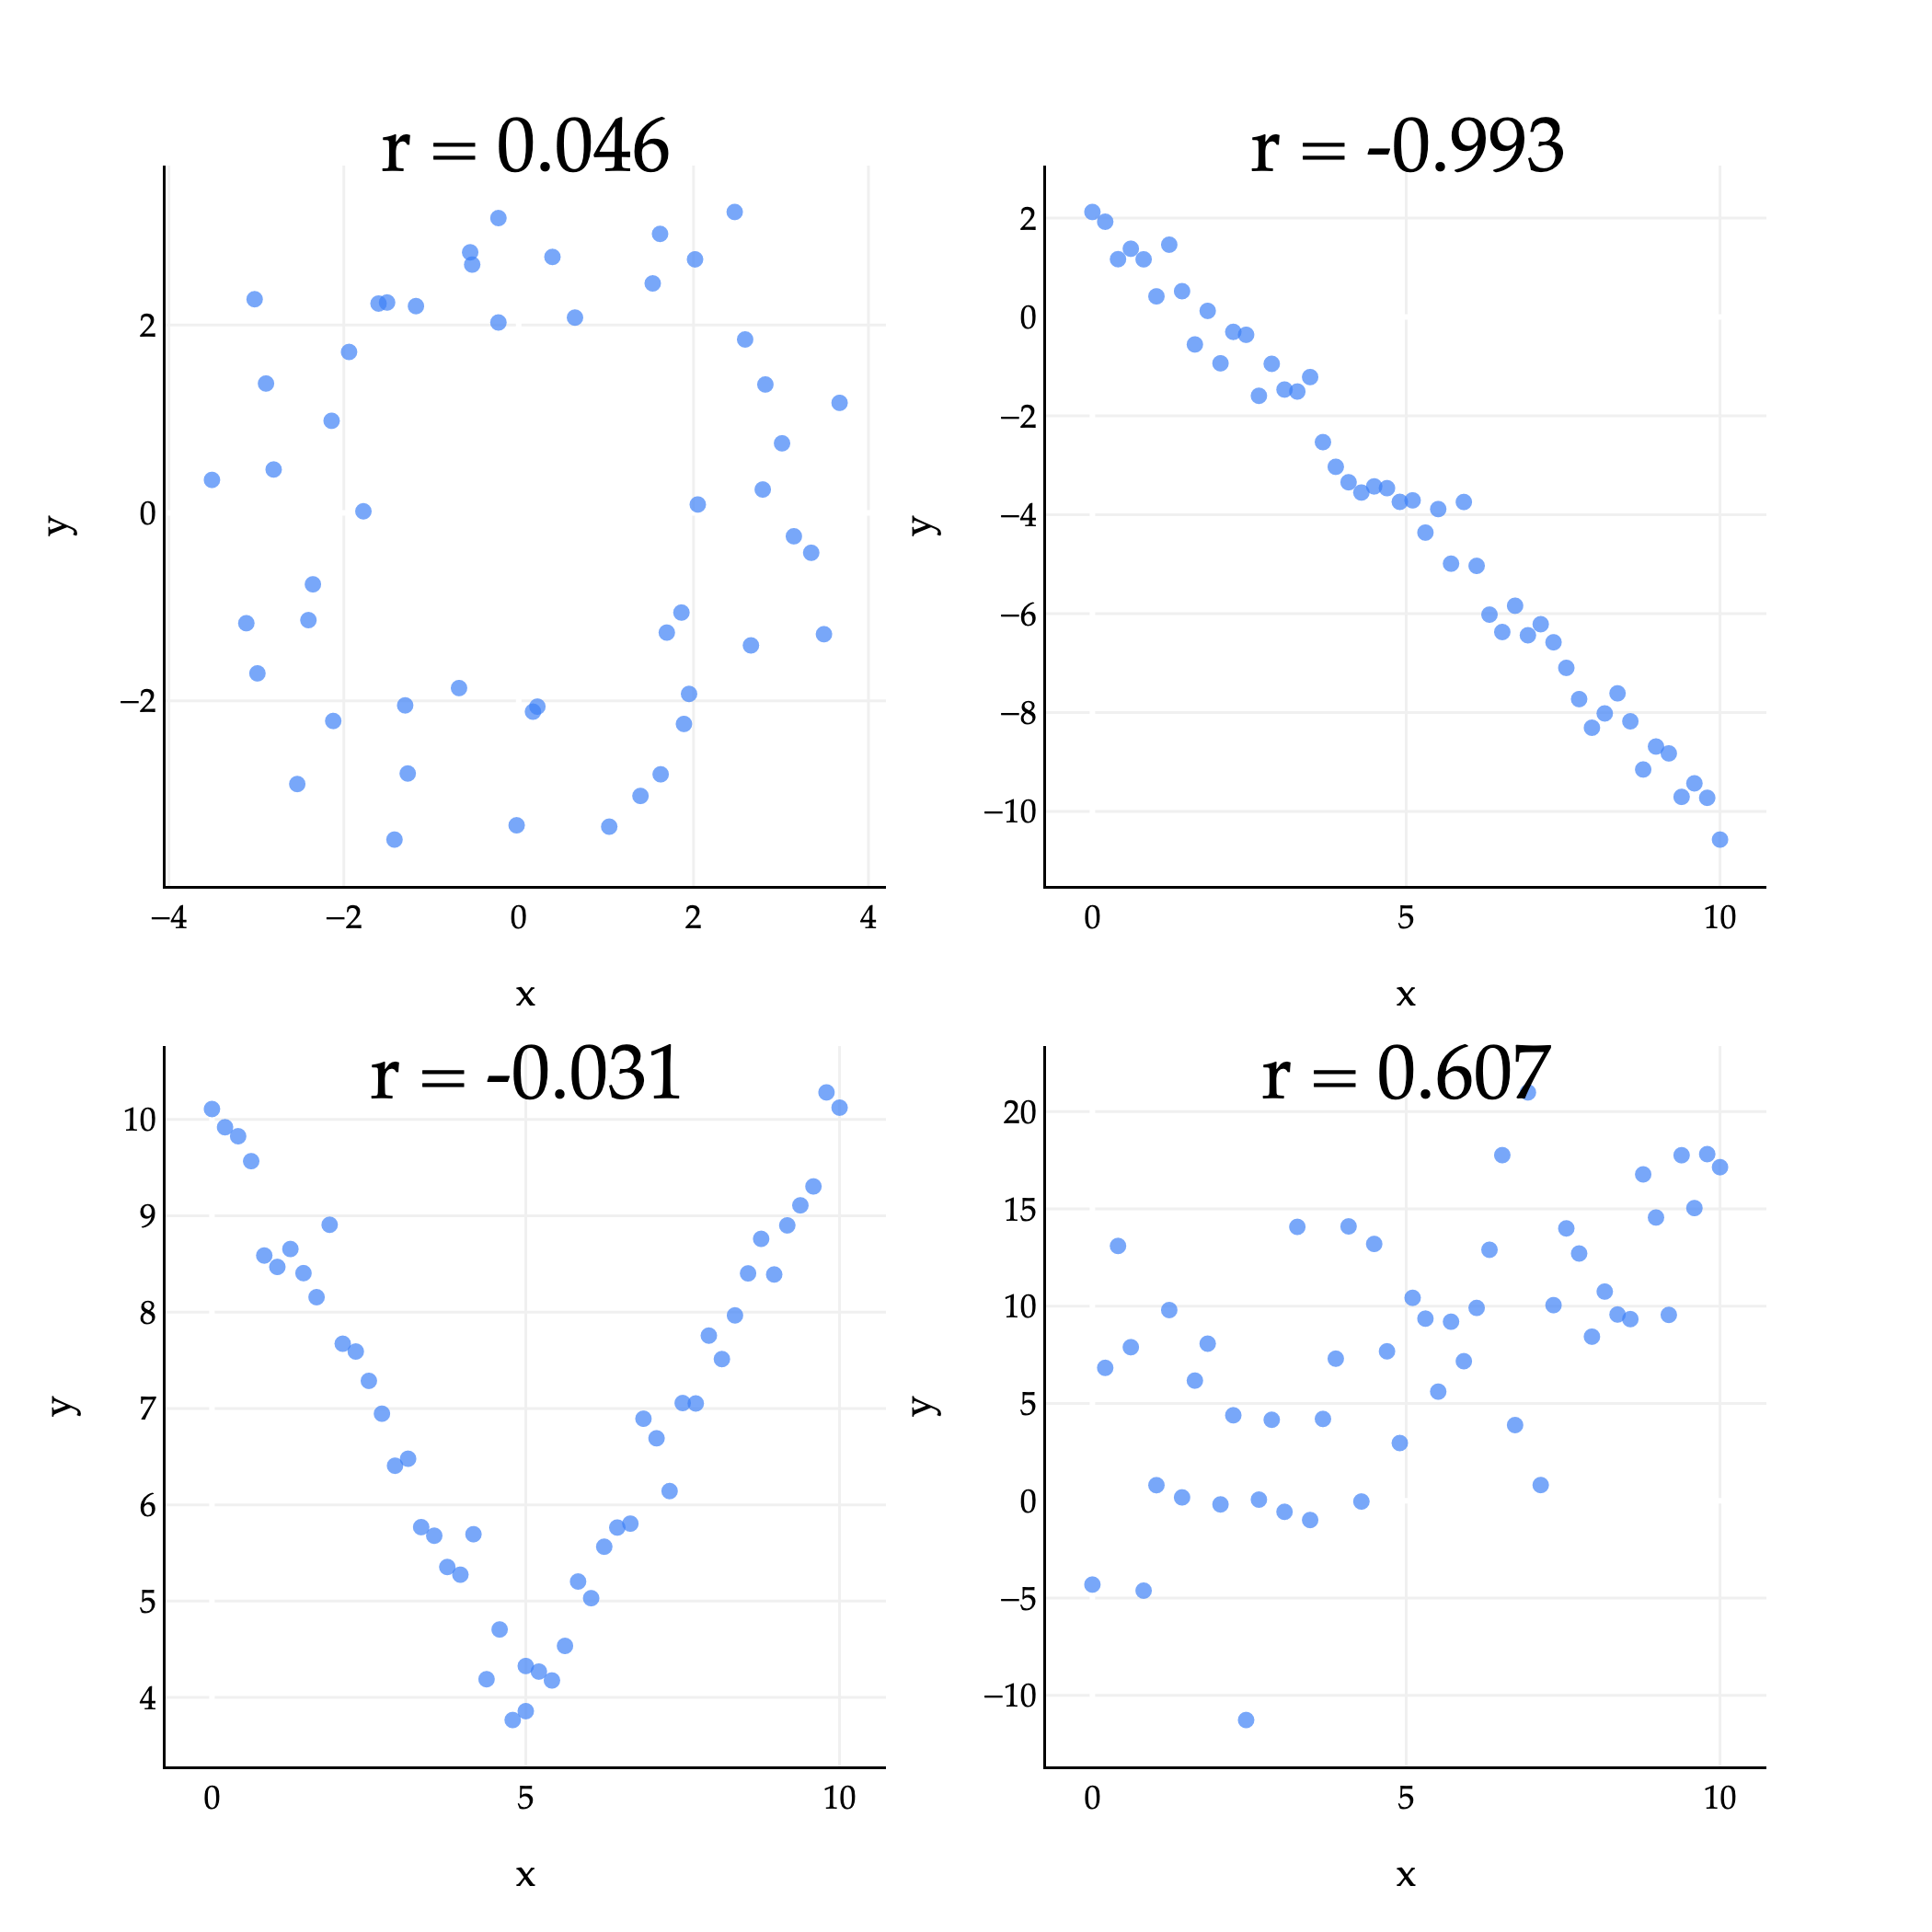

In [353]:
import numpy as np
import plotly.graph_objs as go
from plotly.subplots import make_subplots

np.random.seed(42)

# 1. Roughly circular cloud, little to no correlation
theta = np.linspace(0, 2 * np.pi, 50)
r = 3 + np.random.normal(0, 0.5, size=theta.shape)
x1 = r * np.cos(theta) + np.random.normal(0, 0.3, size=theta.shape)
y1 = r * np.sin(theta) + np.random.normal(0, 0.3, size=theta.shape)
r1 = np.corrcoef(x1, y1)[0, 1]

# 2. Tight positive linear
x2 = np.linspace(0, 10, 50)
y2 = -1.2 * x2 + 2 + np.random.normal(0, 0.5, size=x2.shape)
r2 = np.corrcoef(x2, y2)[0, 1]

# 3. V shape (two strong linear trends)
x3_left = np.linspace(0, 5, 25)
y3_left = -1.2 * x3_left + 10 + np.random.normal(0, 0.3, size=x3_left.shape)
x3_right = np.linspace(5, 10, 25)
y3_right = 1.2 * x3_right - 2 + np.random.normal(0, 0.3, size=x3_right.shape)
x3 = np.concatenate([x3_left, x3_right])
y3 = np.concatenate([y3_left, y3_right])
r3 = np.corrcoef(x3, y3)[0, 1]

# 4. Much looser positive linear (increase noise)
x4 = np.linspace(0, 10, 50)
y4 = 1.2 * x4 + 2 + np.random.normal(0, 5.0, size=x4.shape)  # Increased noise from 2.0 to 5.0
r4 = np.corrcoef(x4, y4)[0, 1]

# Use LaTeX for subplot titles and make them much bigger
subplot_titles = [
    r"r = {:.3f}".format(r1),
    r"r = {:.3f}".format(r2),
    r"r = {:.3f}".format(r3),
    r"r = {:.3f}".format(r4)
]

fig = make_subplots(
    rows=2, cols=2,
    subplot_titles=subplot_titles,
    vertical_spacing=0.1
)

fig.add_trace(
    go.Scatter(x=x1, y=y1, mode='markers', marker=dict(color='#3d81f6', opacity=0.7), showlegend=False),
    row=1, col=1
)
fig.add_trace(
    go.Scatter(x=x2, y=y2, mode='markers', marker=dict(color='#3d81f6', opacity=0.7), showlegend=False),
    row=1, col=2
)
fig.add_trace(
    go.Scatter(x=x3_left, y=y3_left, mode='markers', marker=dict(color='#3d81f6', opacity=0.7), showlegend=False),
    row=2, col=1
)
fig.add_trace(
    go.Scatter(x=x3_right, y=y3_right, mode='markers', marker=dict(color='#3d81f6', opacity=0.7), showlegend=False),
    row=2, col=1
)
fig.add_trace(
    go.Scatter(x=x4, y=y4, mode='markers', marker=dict(color='#3d81f6', opacity=0.7), showlegend=False),
    row=2, col=2
)

for i in range(1, 3):
    for j in range(1, 3):
        fig.update_xaxes(
            title_text="x",
            row=i, 
            col=j,
            gridcolor='#f0f0f0',
            showline=True,
            linecolor="black",
            linewidth=1,
        )
        fig.update_yaxes(
            title_text="y", 
            row=i,
            col=j,
            gridcolor='#f0f0f0',
            showline=True,
            linecolor="black",
            linewidth=1,
        )

fig.update_layout(
    height=700, 
    width=700,
    showlegend=False,
    plot_bgcolor='white',
    paper_bgcolor='white',
    margin=dict(l=60, r=60, t=60, b=60),
    font=dict(
        family="Palatino Linotype, Palatino, serif",
        color="black"
    ),
    # Make subplot titles much bigger and use LaTeX
    annotations=[
        dict(
            text=title,
            x=0.225 if idx == 0 else 0.775 if idx == 1 else 0.225 if idx == 2 else 0.775,
            y=0.98 if idx < 2 else 0.4,
            xref="paper",
            yref="paper",
            showarrow=False,
            font=dict(size=28, family="Palatino Linotype, Palatino, serif"),  # Increased from 28 to 36
            align="center"
        )
        for idx, title in enumerate(subplot_titles)
    ]
)
fig.show(renderer="png", scale=3)

The plots above give us some examples of what the correlation coefficient can look like in practice. 
- **Top left ($r = 0.046$):** There's some loose circle-like pattern, but it mostly looks like a random cloud of points. $|r|$ is close to 0, but just happens to be positive.
- **Top right ($r = -0.993$):** The points are very tightly clustered around a line with a negative slope, so $r$ is close to $-1$.
- **Bottom left ($r = -0.031$):** While the points are certainly associated, they are not linearly associated, so the value of $r$ is close to 0. (The shape looks more like a V or parabola than a straight line.)
- **Bottom right ($r = 0.607$):** The points are loosely clustered and follow a roughly linear pattern trending upwards. $r$ is positive, but not particularly large.

The correlation coefficient has some useful properties to be aware of. For one, it's **symmetric**: $r(x, y) = r(y, x)$. If you swap the $x_i$'s and $y_i$'s in its formula, you'll see the result is the same.

$$r = \frac{1}{n} \sum_{i = 1}^n \left( \frac{x_i - \bar{x}}{\sigma_x} \right) \left( \frac{y_i - \bar{y}}{\sigma_y} \right)$$

One way to think of $r$ is that it's the mean of the product of $x$ and $y$, once both variables have been **standardized**. To standardize a collection of numbers $x_1, x_2, \ldots x_n$, you first find the mean $\bar{x}$ and standard deviation $\sigma_x$ of the collection. Then, for each $x_i$, you compute:

$$z_i = \frac{x_i - \bar{x}}{\sigma_x}$$

This tells you how many standard deviations away from the mean each $x_i$ is. For example, if $z_i = -1.5$, that means $x_i$ is 1.5 standard deviations below the mean of $x$. The value of $x_i$ once it's standardized is sometimes called its **z-score**; you _may_ have heard of $z$-scores in the context of curved exam scores.

### Intuition

With this in mind, I'll again state that $r$ is the <span style="color: orange; font-weight: bold;">mean of the</span> <span style="color: #d81b60; font-weight: bold;">product of</span> $x$ and $y$, once both variables <span style="color: #3d81f6; font-weight: bold;">have been standardized</span>:

$$r = {\color{orange} \frac{1}{n} \sum_{i = 1}^n} \underbrace{\left( {\color{#3d81f6} \frac{x_i - \bar{x}}{\sigma_x}} \right)}_{x_i\text{'s $z$-score}} {\color{#d81b60} \times} \underbrace{\left( {\color{#3d81f6} \frac{y_i - \bar{y}}{\sigma_y}} \right)}_{y_i\text{'s $z$-score}}$$

This interpretation of $r$ makes it a bit easier to see _why_ $r$ measures the strength of linear association – because up until now, it must seem like a formula I pulled out of thin air.

If there's positive linear association, then $x_i$ and $y_i$ will usually either both be above their averages, or both be below their averages, meaning that $x_i - \bar{x}$ and $y_i - \bar{y}$ will usually have the same sign. If we multiply two numbers with the same sign – either both positive or both negative – then the product will be positive.

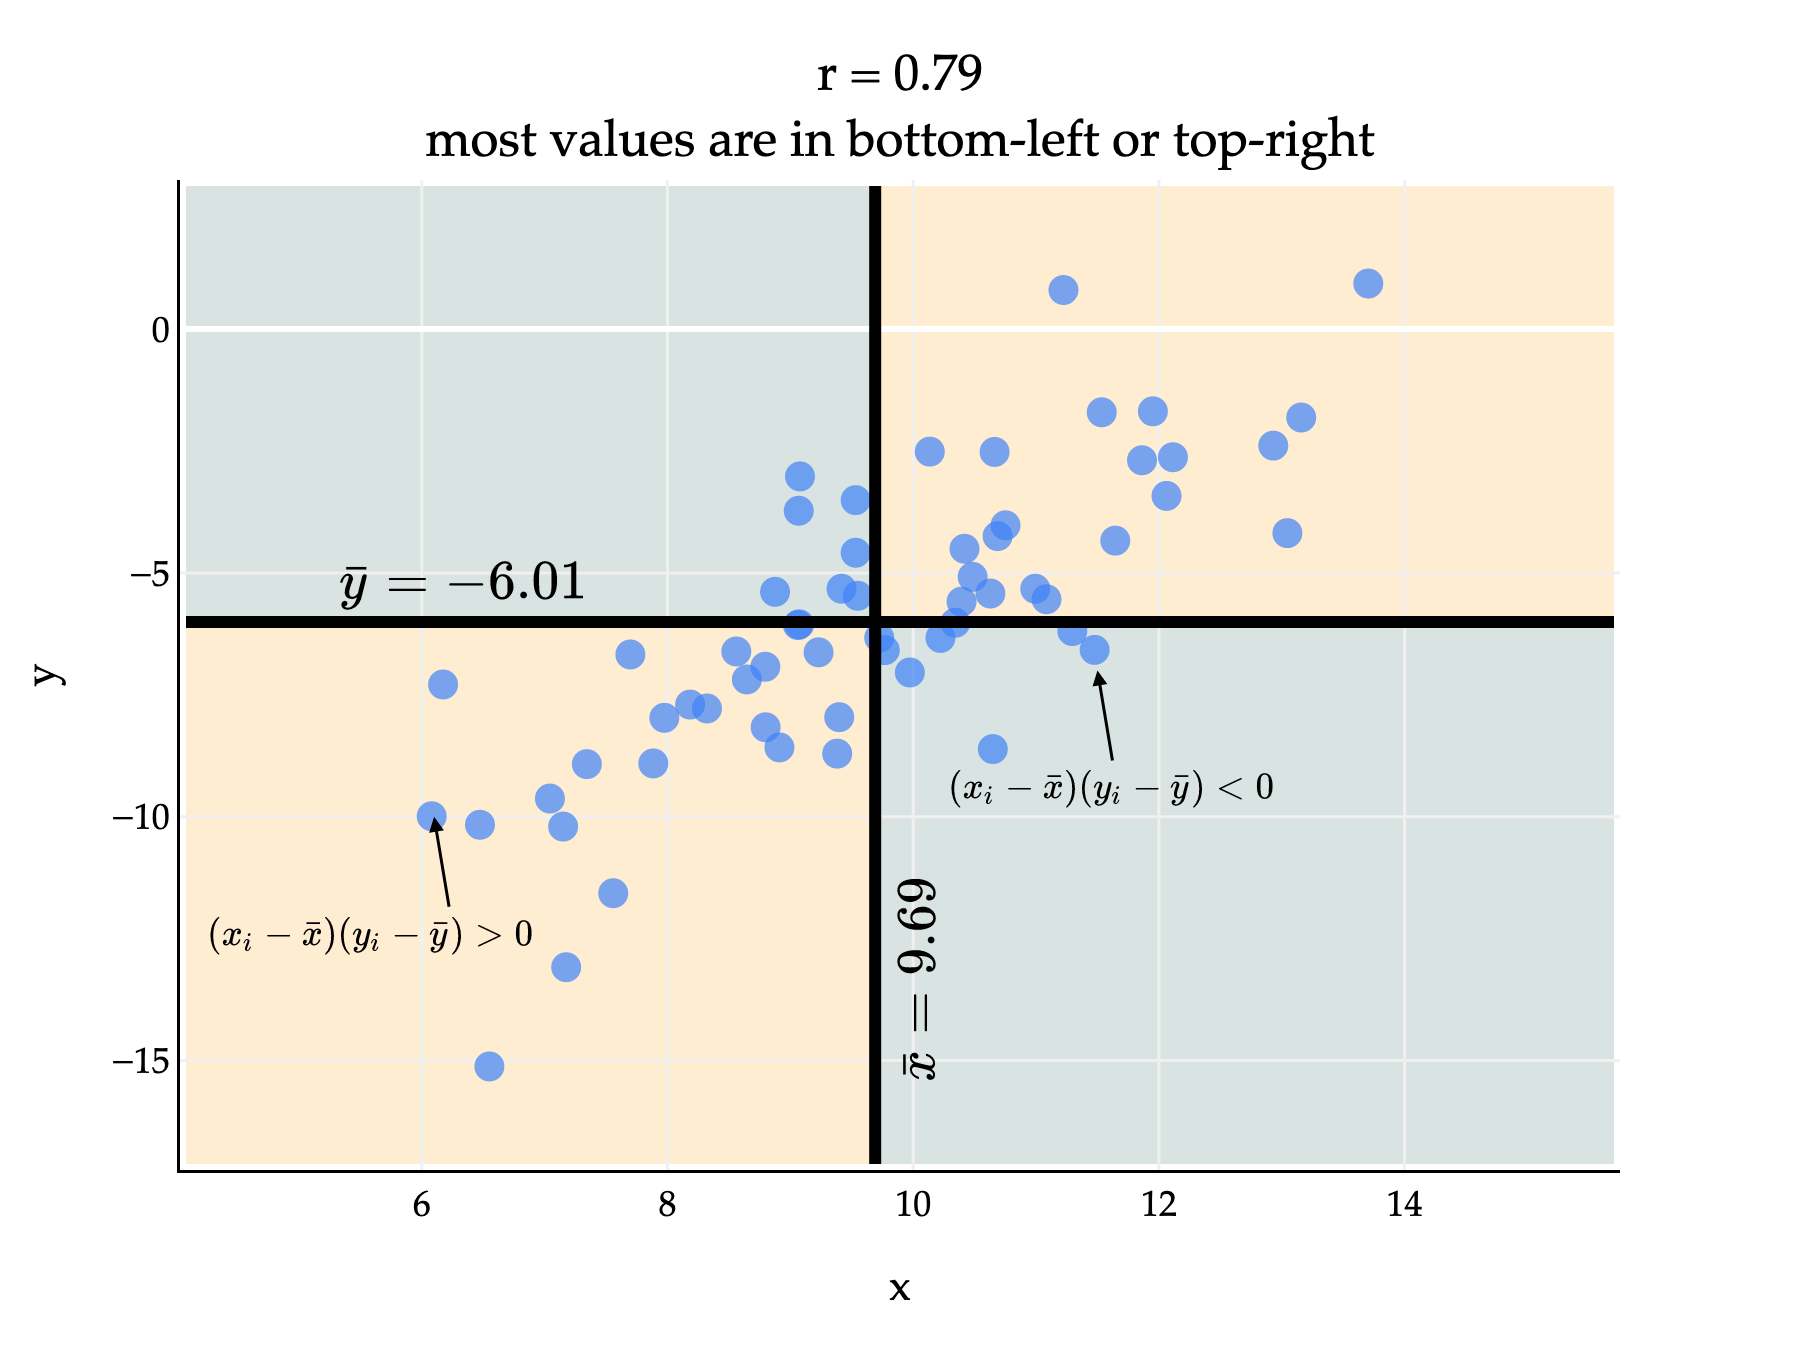

In [355]:
import numpy as np
import plotly.graph_objects as go

np.random.seed(42)
n = 60
x = np.random.normal(10, 2, n)
# Create y with r ≈ 0.75 to x, y mean ≈ -6
r = 0.75
y = r * (x - np.mean(x)) / np.std(x) * 3 + np.random.normal(0, np.sqrt(1 - r**2) * 3, n) - 6

x_mean = np.mean(x)
y_mean = np.mean(y)
corr = np.corrcoef(x, y)[0, 1]

x_min, x_max = min(x)-2, max(x)+2
y_min, y_max = min(y)-2, max(y)+2

# Compute (x - x̄), (y - ȳ), and their product for each point
x_centered = x - x_mean
y_centered = y - y_mean
product = x_centered * y_centered

# Prepare custom hover text
hover_text = [
    f"x = {xi:.2f}<br>y = {yi:.2f}<br>x - ȳ = {xc:.2f}<br>y - ȳ = {yc:.2f}<br>product = {p:.2f}"
    .replace("x - ȳ", "x - \\bar{{x}}").replace("y - ȳ", "y - \\bar{{y}}")
    for xi, yi, xc, yc, p in zip(x, y, x_centered, y_centered, product)
]

fig = go.Figure()

# Shade quadrants: top right and bottom left green, others red
# Top right (x > x_mean, y > y_mean): light orange
fig.add_shape(
    type="rect",
    x0=x_mean, x1=x_max,
    y0=y_mean, y1=y_max,
    fillcolor="rgba(255, 183, 77, 0.25)",  # light orange
    line=dict(width=0),
    layer="below"
)
# Bottom left (x < x_mean, y < y_mean): light orange
fig.add_shape(
    type="rect",
    x0=x_min, x1=x_mean,
    y0=y_min, y1=y_mean,
    fillcolor="rgba(255, 183, 77, 0.25)",  # light orange
    line=dict(width=0),
    layer="below"
)
# Top left (x < x_mean, y > y_mean): light #004d40
fig.add_shape(
    type="rect",
    x0=x_min, x1=x_mean,
    y0=y_mean, y1=y_max,
    fillcolor="rgba(0, 77, 64, 0.15)",  # light #004d40
    line=dict(width=0),
    layer="below"
)
# Bottom right (x > x_mean, y < y_mean): light #004d40
fig.add_shape(
    type="rect",
    x0=x_mean, x1=x_max,
    y0=y_min, y1=y_mean,
    fillcolor="rgba(0, 77, 64, 0.15)",  # light #004d40
    line=dict(width=0),
    layer="below"
)

fig.add_trace(go.Scatter(
    x=x, y=y,
    mode='markers',
    marker=dict(size=10, color="#3D81F6", line=dict(width=0), opacity=0.7),
    showlegend=False,
    hovertemplate=(
        "x = %{x:.2f}<br>"
        "y = %{y:.2f}<br>"
        "x - &#772;x = %{customdata[0]:.2f}<br>"
        "y - &#772;y = %{customdata[1]:.2f}<br>"
        "product = %{customdata[2]:.2f}<extra></extra>"
    ),
    customdata=np.stack([x_centered, y_centered, product], axis=-1)
))

# Add thick black vertical line at x = mean(x)
fig.add_shape(
    type="line",
    x0=x_mean, x1=x_mean,
    y0=y_min, y1=y_max,
    line=dict(color="black", width=4)
)
# Add thick black horizontal line at y = mean(y)
fig.add_shape(
    type="line",
    x0=x_min, x1=x_max,
    y0=y_mean, y1=y_mean,
    line=dict(color="black", width=4)
)

# Annotate mean of x along the y-axis, vertical and rotated, using \bar{x}
fig.add_annotation(
    x=x_mean+0.1,
    y=-14,
    text=f"$\\bar{{x}} = {x_mean:.2f}$",
    showarrow=False,
    font=dict(size=20, color="black"),
    textangle=-90,
    xanchor="left",
    yanchor="middle"
)

# Annotate mean of y along the x-axis, horizontal, using \bar{y}
fig.add_annotation(
    x=6,
    y=y_mean+0.5,
    text=f"$\\bar{{y}} = {y_mean:.2f}$",
    showarrow=False,
    font=dict(size=20, color="black"),
    xanchor="center",
    yanchor="bottom"
)

fig.update_layout(
    title={
        'text': f"r = {corr:.2f}<br>most values are in bottom-left or top-right",
        'x': 0.5,
        'xanchor': 'center'
    },
    xaxis_title="x",
    yaxis_title="y",
    width=600,
    height=450,
    plot_bgcolor='white',
    font=dict(
        family="Palatino Linotype, Palatino, serif",
        color="black"
    ),
    margin=dict(l=60, r=60, t=60, b=60)
)
fig.update_xaxes(
    gridcolor='#f0f0f0',
    showline=True,
    linecolor="black",
    linewidth=1,
)
fig.update_yaxes(
    gridcolor='#f0f0f0',
    showline=True,
    linecolor="black",
    linewidth=1,
)

# Add annotation with arrow to (6, -10)
fig.add_annotation(
    x=6.1,
    y=-10,
    text="$(x_i - \\bar{x})(y_i - \\bar{y}) > 0$",
    showarrow=True,
    arrowhead=2,
    arrowsize=1,
    arrowwidth=1,
    arrowcolor="black",
    ax=5,  # horizontal offset in pixels
    ay=30, # vertical offset in pixels
    font=dict(size=12, color="black"),
    xanchor="center",
    yanchor="top"
)

# Add annotation with arrow to (6, -10)
fig.add_annotation(
    x=11.5,
    y=-7,
    text="$(x_i - \\bar{x})(y_i - \\bar{y}) < 0$",
    showarrow=True,
    arrowhead=2,
    arrowsize=1,
    arrowwidth=1,
    arrowcolor="black",
    ax=5,  # horizontal offset in pixels
    ay=30, # vertical offset in pixels
    font=dict(size=12, color="black"),
    xanchor="center",
    yanchor="top"
)

fig.show(renderer="png", scale=3)


Since most points are in the <span style="color:orange; font-weight: bold">bottom-left and top-right quadrants</span>, most of the products $(x_i - \bar{x})(y_i - \bar{y})$ are positive. This means that $r$, which is the average of these products divided by the standard deviations of $x$ and $y$, will be <span style="color:orange; font-weight: bold">positive</span> too. (We divide by the standard deviations to ensure that $-1 \leq r \leq 1$.)

Above, $r$ is positive but not exactly 1, since there are several points in the bottom-right and top-left quadrants, who would have a negative product $(x_i - \bar{x})(y_i - \bar{y})$ and bring down the average product.

If there's negative linear association, then typically it'll be the case that $x_i$ is above average while $y_i$ is below average, or vice versa. This means that $x_i - \bar{x}$ and $y_i - \bar{y}$ will usually have opposite signs, and when they have opposite signs, their product will be negative. If most points have a negative product, then $r$ will be negative too.

### Another Example

Let me show you another example that gets at the heart of how the correlation formula is defined. Consider the following two datasets.

- Dataset A: $(1, 5), (2, 6), (3, 7), (4, 8)$
- Dataset B: $(1, 8), (2, 5), (3, 6), (4, 7)$

Both datasets use the same $x$ and $y$ values, but the pairings are different, and so their scatter plots look quite different.

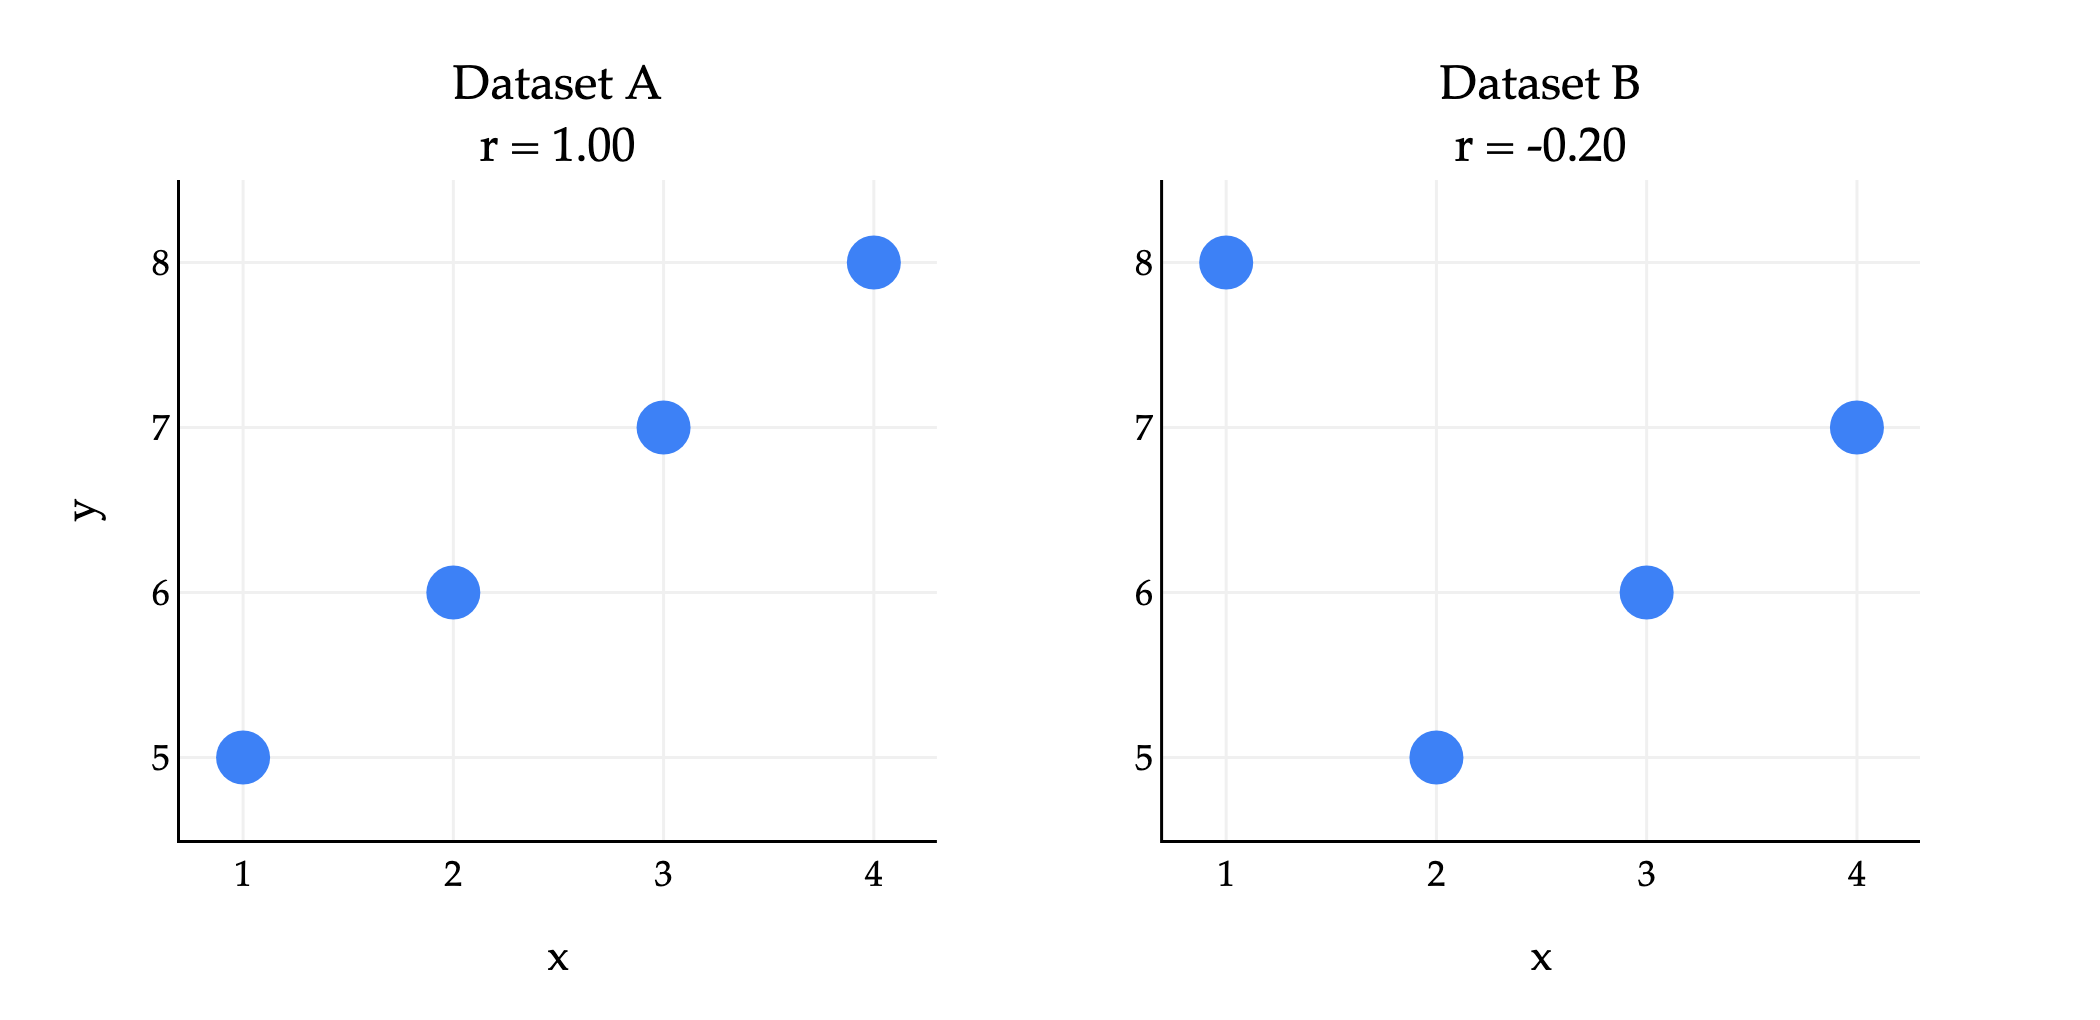

In [8]:
import numpy as np
import plotly.graph_objects as go
from plotly.subplots import make_subplots

# Dataset A: perfect positive linear relationship (r = 1)
x = np.array([1, 2, 3, 4])
y_a = np.array([5, 6, 7, 8])

# Dataset B: scramble the y values (r ≈ 0.4)
y_b = np.array([8, 5, 6, 7])

x_bar = np.mean(x)
y_a_bar = np.mean(y_a)
y_b_bar = np.mean(y_b)

r_a = np.corrcoef(x, y_a)[0, 1]
r_b = np.corrcoef(x, y_b)[0, 1]

# Create subplots
fig = make_subplots(
    rows=1, cols=2,
    subplot_titles=(
        f"Dataset A<br>r = {r_a:.2f}",
        f"Dataset B<br>r = {r_b:.2f}"
    ),
    horizontal_spacing=0.13,
)

# Dataset A
fig.add_trace(go.Scatter(
    x=x,
    y=y_a,
    mode="markers",
    marker=dict(color="#3D81F6", size=18),
    showlegend=False
), row=1, col=1)

# Dataset B
fig.add_trace(go.Scatter(
    x=x,
    y=y_b,
    mode="markers",
    marker=dict(color="#3D81F6", size=18),
    showlegend=False
), row=1, col=2)

for i in [1, 2]:
    fig.update_xaxes(
        title_text="x",
        range=[0.7, 4.3],
        showline=True,
        linecolor="black",
        linewidth=1,
        gridcolor="#f0f0f0",
        tickfont=dict(size=12),
        title_font=dict(size=14),
        row=1, col=i
    )
    fig.update_yaxes(
        title_text="y" if i == 1 else None,
        range=[4.5, 8.5],
        showline=True,
        linecolor="black",
        linewidth=1,
        gridcolor="#f0f0f0",
        tickfont=dict(size=12),
        title_font=dict(size=14),
        row=1, col=i
    )

fig.update_layout(
    plot_bgcolor='white',
    paper_bgcolor='white',
    margin=dict(l=60, r=60, t=60, b=60),
    width=700,
    height=340,
    font=dict(family="Palatino Linotype, Palatino, serif", color="black", size=13),
    showlegend=False
)

fig.show(renderer='png', scale=3)

In both datasets, $\bar{x}$, $\bar{y}$, $\sigma_x$, and $\sigma_y$ are the same. But, their correlation coefficients are quite different, because the pairings between $x_i$'s and $y_i$'s are different.

---

## Preserving Correlation

Since $r$ measures how closely points cluster around a line, it is invariant to units of measurement. Whether you use feet or meters to measure distance, or dollars or yen to measure price, the correlation between two variables will be the same.

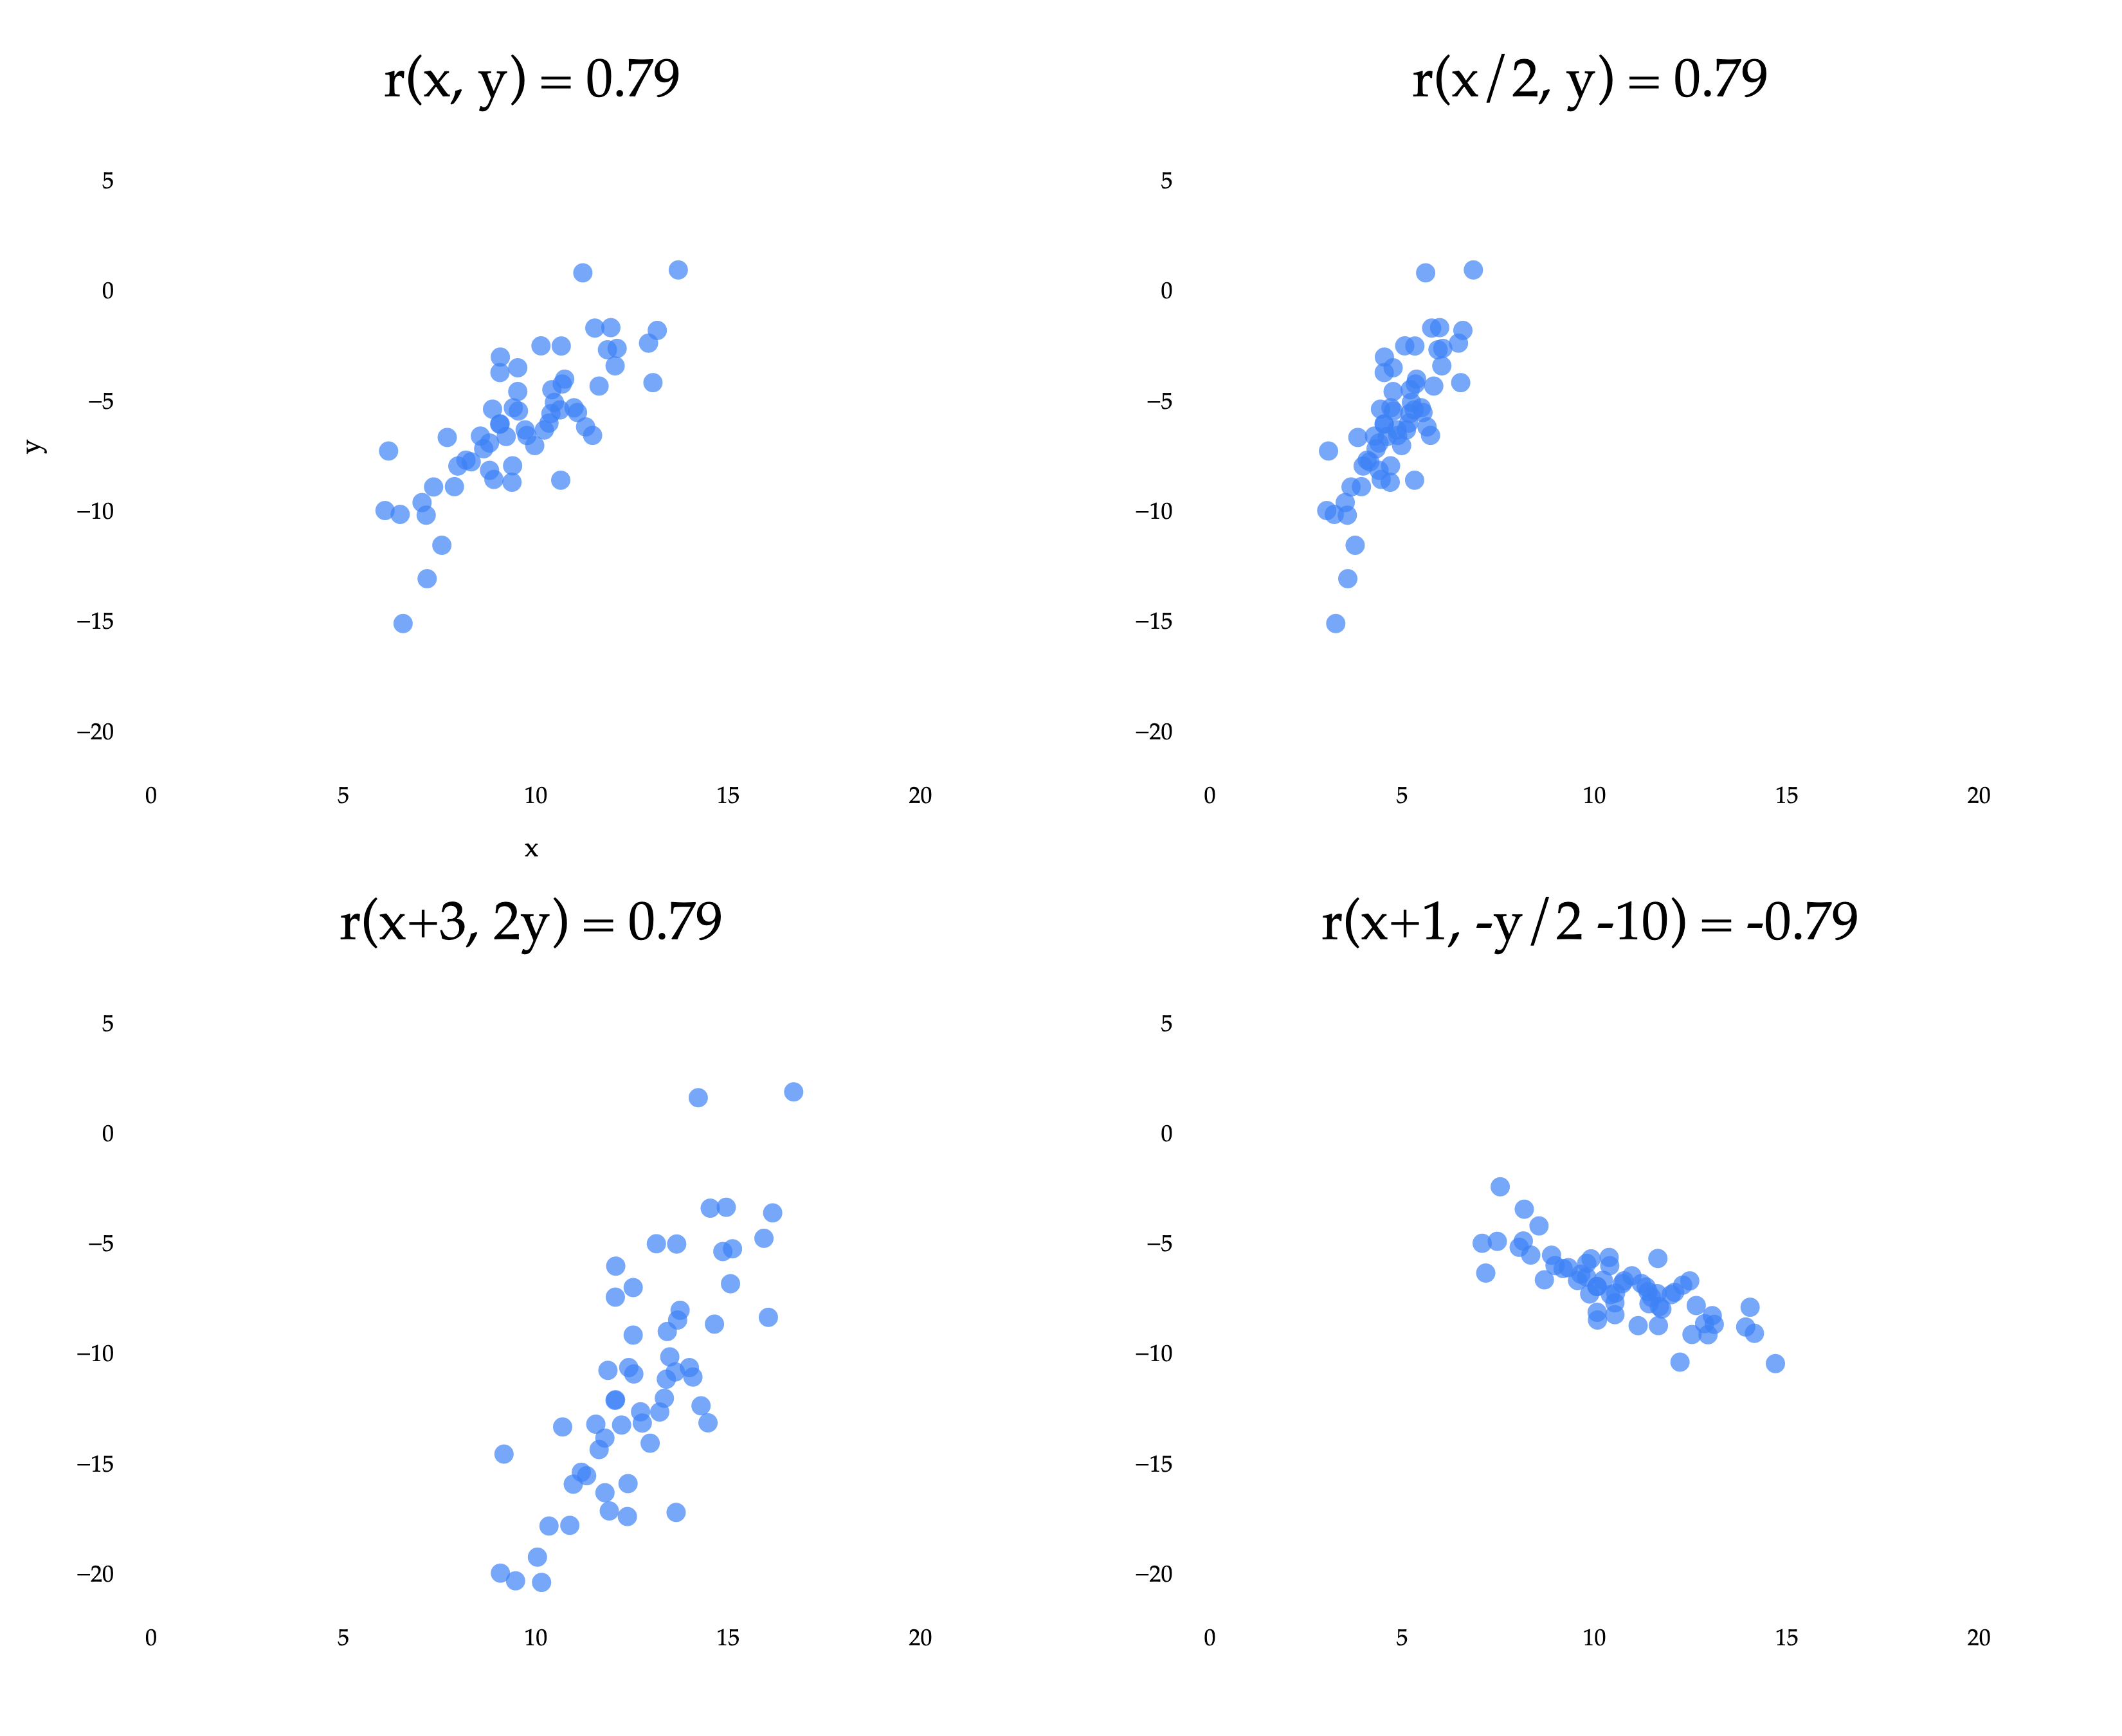

In [373]:
import numpy as np
import plotly.graph_objects as go
from plotly.subplots import make_subplots

np.random.seed(42)
n = 60
x = np.random.normal(10, 2, n)
r = 0.75
y = r * (x - np.mean(x)) / np.std(x) * 3 + np.random.normal(0, np.sqrt(1 - r**2) * 3, n) - 6

# Compute axis limits from original data (to keep axes fixed)
x_min, x_max = min(x)-7, max(x)+7
y_min, y_max = min(y)-7, max(y)+7

# Prepare transformed datasets and their correlations
transforms = [
    (x, y,         r"x(x,y)",      np.corrcoef(x, y)[0, 1], "r(x,y)"),
    (x / 2, y,         r"x(x/2, y)",      np.corrcoef(x / 2, y)[0, 1], "r(x/2, y)"),
    (x + 3, 2 * y,       r"x(x+3, 2y)",      np.corrcoef(x + 3, 2 * y)[0, 1], "r(x+3, 2y)"),
    (x + 1, -y/2 - 10,    r"x(x+1, -y/2 - 10)",  np.corrcoef(x + 1, -y/2 - 10)[0, 1], "r(x+1, -y/2 - 1)"),
]

# For the last plot, show -r in the title (negate the correlation)
transforms[-1] = (transforms[-1][0], transforms[-1][1], transforms[-1][2], -np.corrcoef(x, y)[0, 1], "r(-0.5x, y+1)")

titles = [
    f"r(x, y) = {transforms[0][3]:.2f}",
    f"r(x/2, y) = {transforms[1][3]:.2f}",
    f"r(x+3, 2y) = {transforms[2][3]:.2f}",
    f"r(x+1, -y/2 -10) = {transforms[3][3]:.2f}",
]

fig = make_subplots(
    rows=2, cols=2,
    subplot_titles=titles,
    horizontal_spacing=0.12,
    vertical_spacing=0.12
)

for i, (x_t, y_t, _, _, _) in enumerate(transforms):
    row = i // 2 + 1
    col = i % 2 + 1
    fig.add_trace(
        go.Scatter(
            x=x_t, y=y_t,
            mode='markers',
            marker=dict(size=10, color="#3D81F6", line=dict(width=0), opacity=0.7),
            showlegend=False,
            hovertemplate="x = %{x:.2f}<br>y = %{y:.2f}<extra></extra>"
        ),
        row=row, col=col
    )
    fig.update_xaxes(range=[x_min, x_max], row=row, col=col)
    fig.update_yaxes(range=[y_min, y_max], row=row, col=col)

fig.update_layout(
    height=900,
    width=1100,
    plot_bgcolor='white',
    paper_bgcolor='white',
    margin=dict(l=60, r=60, t=60, b=60),
    font=dict(
        family="Palatino Linotype, Palatino, serif",
        color="black",
    ),
    xaxis_title="x",
    yaxis_title="y",
    annotations=[
        dict(font=dict(size=28, family="Palatino Linotype, Palatino, serif"))
    ]
)

fig.show(renderer="png", scale=3)


The top left scatter plot is the same as in the previous example, where we reasoned about why $r$ is positive. The other three plots result from applying **linear transformations** to the $x$ and/or $y$ variables independently. A linear transformation of $x$ is any function of the form $ax + b$, and a linear transformation of $y$ is any function of the form $cy + d$. (This is an idea we'll revisit more in [Chapter 6.1](../06_linear_transformations_and_projections/01-linear-transformations.ipynb).)

Notice that three of the four plots have the same $r$ of approximately $0.79$. The bottom right plot has an $r$ of approximately $-0.79$, because the $y$ coordinates were multiplied by a negative constant. What we're seeing is that **the correlation coefficient is invariant to linear transformations of the two variables independently**.

Put in real-world terms: it doesn't matter if you measure commute times in hours, minutes, or seconds, the correlation between departure time and commute time will be the same in all three cases.

---

## Correlation and the Regression Line

Since $r$ measures how closely points cluster around a line, it shouldn't be all that surprising that $r$ has something to do with $w_1^*$, the slope of the regression line.

It turns out that:

$$w_1^* = \underbrace{\frac{\sum_{i=1}^n (x_i - \bar{x})(y_i - \bar{y})}{\sum_{i=1}^n (x_i - \bar{x})^2}}_\text{from earlier} = \boxed{r \frac{\sigma_y}{\sigma_x}}$$

This is my preferred version of the formula for the optimal slope – it's easy to use and interpret. I've hidden the proof behind a dropdown menu below, but you really should attempt it on your own (and then read it), since it helps build familiarity with how the various components of the formula for $r$ and $w_1^*$ are related.

:::{seealso} Proof that $w_1^* = r\frac{\sigma_y}{\sigma_x}$
:class: dropdown
First, let's show that we can express $\sum_{i=1}^n (x_i-\bar x)^2$ in terms of $\sigma_x$:
$$
\begin{aligned}
&\sigma_x=\sqrt{\frac{1}{n}\sum_{i=1}^n (x_i - \bar{x})^2} \\
&\sigma_x^2=\frac{1}{n}\sum_{i=1}^n (x_i - \bar{x})^2 \\
&n\sigma_x^2=\sum_{i=1}^n (x_i - \bar{x})^2 \\
\end{aligned}
$$

Now, let's prove that $w_1^* = r\frac{\sigma_y}{\sigma_x}$:
$$
\begin{aligned}
&r\frac{\sigma_y}{\sigma_x}=\frac{1}{n}\sum_{i=1}^n \left(\frac{x_i - \bar{x}}{\sigma_x} \right) \left(\frac{y_i - \bar{y}}{\sigma_y} \right)\cdot \frac{\sigma_y}{\sigma_x} \\
&=\frac{1}{n}\sum_{i=1}^n \frac{(x_i - \bar{x})(y_i - \bar{y})}{\sigma_x^2} \\
&= \frac{\sum_{i=1}^n(x_i - \bar{x})(y_i - \bar{y})}{n\sigma_x^2} \\
&=\frac{\displaystyle\sum_{i=1}^n(x_i - \bar{x})(y_i - \bar{y})}{\displaystyle\sum_{i=1}^n (x_i - \bar{x})^2} \\
&=w_1^*
\end{aligned}
$$
:::

The simpler formula above implies that the sign of the slope is the same as the sign of $r$, which seems reasonable: if the direction of the linear association is negative, the best-fitting slope should be, too.

So, all in one place:

$$w_1^* = \frac{\sum_{i=1}^n (x_i - \bar{x})(y_i - \bar{y})}{\sum_{i=1}^n (x_i - \bar{x})^2} = r \frac{\sigma_y}{\sigma_x}, \qquad w_0^* = \bar{y} - w_1^* \bar{x}$$

This new formula for the slope also gives us insight into how the spread of $x$ ($\sigma_x$) and $y$ ($\sigma_y$) affects the slope. If $y$ is more spread out than $x$, the points on the scatter plot will be stretched out vertically, which will make the best-fitting slope steeper.

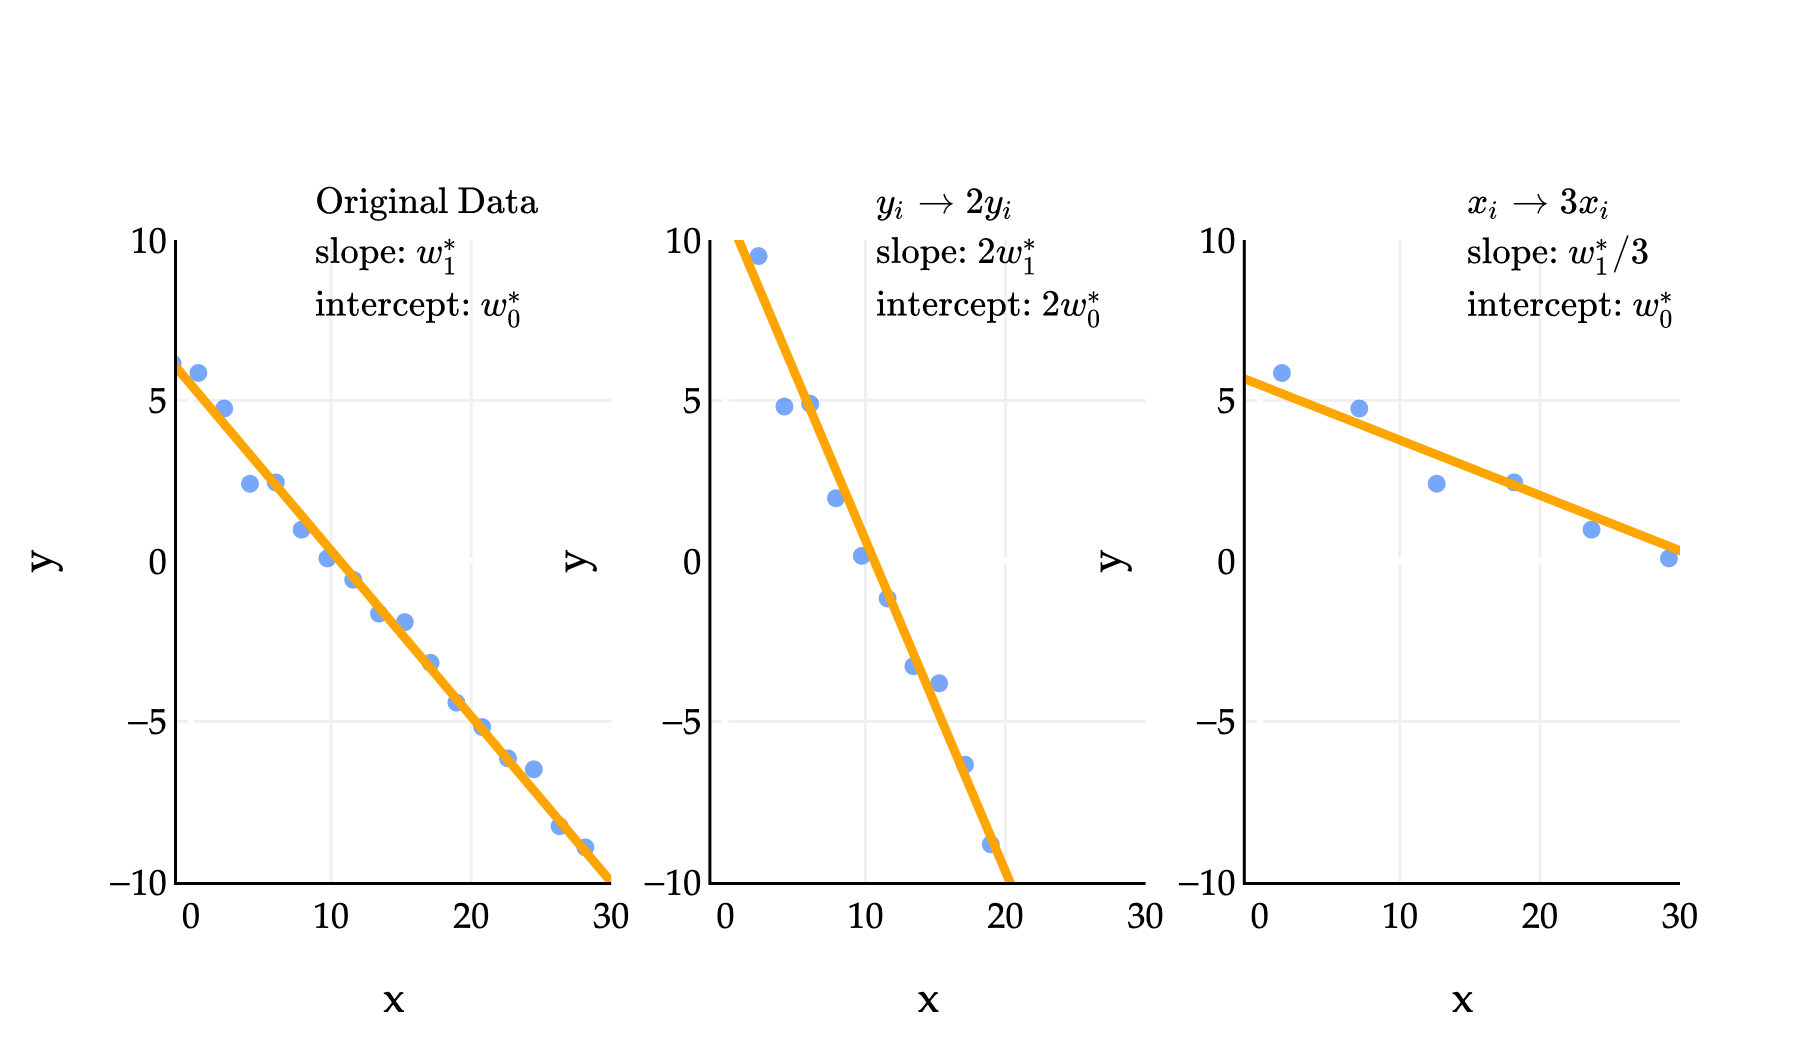

In [56]:
import numpy as np
import plotly.graph_objects as go
from plotly.subplots import make_subplots

# Create base data: negative linear association, shallow slope
np.random.seed(0)
x_base = np.linspace(-5, 30, 20)
y_base = -0.5 * x_base + 5 + np.random.normal(0, 0.5, size=x_base.shape)

x_range = [-1, 30]
y_range = [-10, 10]

# Create subplots: 1 row, 3 columns
fig = make_subplots(
    rows=1, cols=3,
    subplot_titles=('', '', '')  # We'll update these with custom annotations
)

# Base plot
fig.add_trace(
    go.Scatter(x=x_base, y=y_base, mode='markers', marker=dict(color='#3d81f6', opacity=0.7)),
    row=1, col=1
)
# Regression line for base
m1, b1 = np.polyfit(x_base, y_base, 1)
fig.add_trace(
    go.Scatter(x=x_base, y=m1 * x_base + b1, mode='lines', line=dict(color='orange', width=3), showlegend=False),
    row=1, col=1
)

# X stretched plot (y values stretched by factor of 2)
x_new, y_new = x_base, y_base * 2
fig.add_trace(
    go.Scatter(x=x_new, y=y_new, mode='markers', marker=dict(color='#3d81f6', opacity=0.7)),
    row=1, col=2
)
m2, b2 = np.polyfit(x_new, y_new, 1)
fig.add_trace(
    go.Scatter(x=x_new, y=m2 * x_new + b2, mode='lines', line=dict(color='orange', width=3), showlegend=False),
    row=1, col=2
)

# Y stretched plot (x values stretched by factor of 3)
x_new, y_new = x_base * 3, y_base
fig.add_trace(
    go.Scatter(x=x_new, y=y_new, mode='markers', marker=dict(color='#3d81f6', opacity=0.7)),
    row=1, col=3
)
m3, b3 = np.polyfit(x_new, y_new, 1)
fig.add_trace(
    go.Scatter(x=x_new, y=m3 * x_new + b3, mode='lines', line=dict(color='orange', width=3), showlegend=False),
    row=1, col=3
)

# Set axes ranges and labels for all subplots
for i in range(1, 4):
    fig.update_xaxes(range=x_range, title_text="x", row=1, col=i, showline=True, linecolor="black", gridcolor="#f0f0f0")
    fig.update_yaxes(range=y_range, title_text="y", row=1, col=i, showline=True, linecolor="black", gridcolor="#f0f0f0")

# Add custom annotations for titles with slope and intercept information
fig.add_annotation(
    text=r"$\text{Original Data} \\ \text{slope: } w_1^* \\ \text{intercept: } w_0^*$",
    x=0.167, y=1.1, xref="paper", yref="paper",
    showarrow=False, font=dict(size=12, color="black"),
    xanchor="center"
)

fig.add_annotation(
    text=r"$y_i \rightarrow 2y_i \\ \text{slope: } 2w_1^* \\ \text{intercept: } 2w_0^*$",
    x=0.54, y=1.1, xref="paper", yref="paper",
    showarrow=False, font=dict(size=12, color="black"),
    xanchor="center"
)

fig.add_annotation(
    text=r"$x_i \rightarrow 3x_i \\ \text{slope: } w_1^* / 3 \\ \text{intercept: } w_0^*$",
    x=1.0, y=1.1, xref="paper", yref="paper",
    showarrow=False, font=dict(size=12, color="black"),
    # xanchor="left"
)

fig.update_layout(
    height=350, width=600,
    showlegend=False,
    plot_bgcolor='white',
    paper_bgcolor='white',
    margin=dict(l=40, r=40, t=80, b=40),  # Increased top margin for titles
    font=dict(
        family="Palatino Linotype, Palatino, serif",
        color="black"
    )
)

fig.show(renderer='png', scale=3)

In the middle example above, $y_i \rightarrow 2y_i$ means that we replaced each $y_i$ in the dataset with $2y_i$. In that example, the slope and intercept of the regression line both doubled. In the third example, where we replaced each $x_i$ with $3x_i$, the slope was divided by 3, while the intercept remained. One of the problems in Homework 2 has you prove these sorts of results, and you can do so by relying on the formula for $w_1^*$ that involves $r$; **note that all three datasets above have the same $r$**.


:::{tip} Activity 1
:class: dropdown

This activity is an old exam question, taken from an exam that used to allow calculators. Part of it also appears in Lab 3.

1. First, suppose we minimize mean squared error to fit a simple linear regression line that **uses the square footage of a house to predict its price**. The resulting line has an intercept of $w_0^*$ and a slope of $w_1^*$. In other words:

    $$\text{predicted price}_i = w_0^* + w_1^* \cdot \text{square footage}_i$$

    We're now interested in minimizing mean squared error to find a simple linear regression line that uses **price to predict square footage**. Suppose this new regression line has an intercept of $\beta_0^*$ and a slope of $\beta_1^*$.

    What is $\beta_1^*$? Give your answer as an expression in terms of $n$, $r$, $w_0^*$, and/or $w_1^*$.

2. Given that:
- $n = 100$
- $r = 0.6$
- $w_0^* = 1000$
- $w_1^* = 250$|
- The average square footage of houses in the dataset is $2000$

What is $\beta_0^*$? Your answer should be a constant with no variables. (Once you're able to express $\beta_0^*$ in terms of constants only, you can stop simplifying your answer.)
:::

### Example: Anscombe's Quartet

The correlation coefficient is just one number that describes the linear association between two variables; it doesn't tell us _everything_. 

Consider the famous example of Anscombe's quartet, which consists of four datasets that all have the same mean, standard deviation, and correlation coefficient, but look very different.

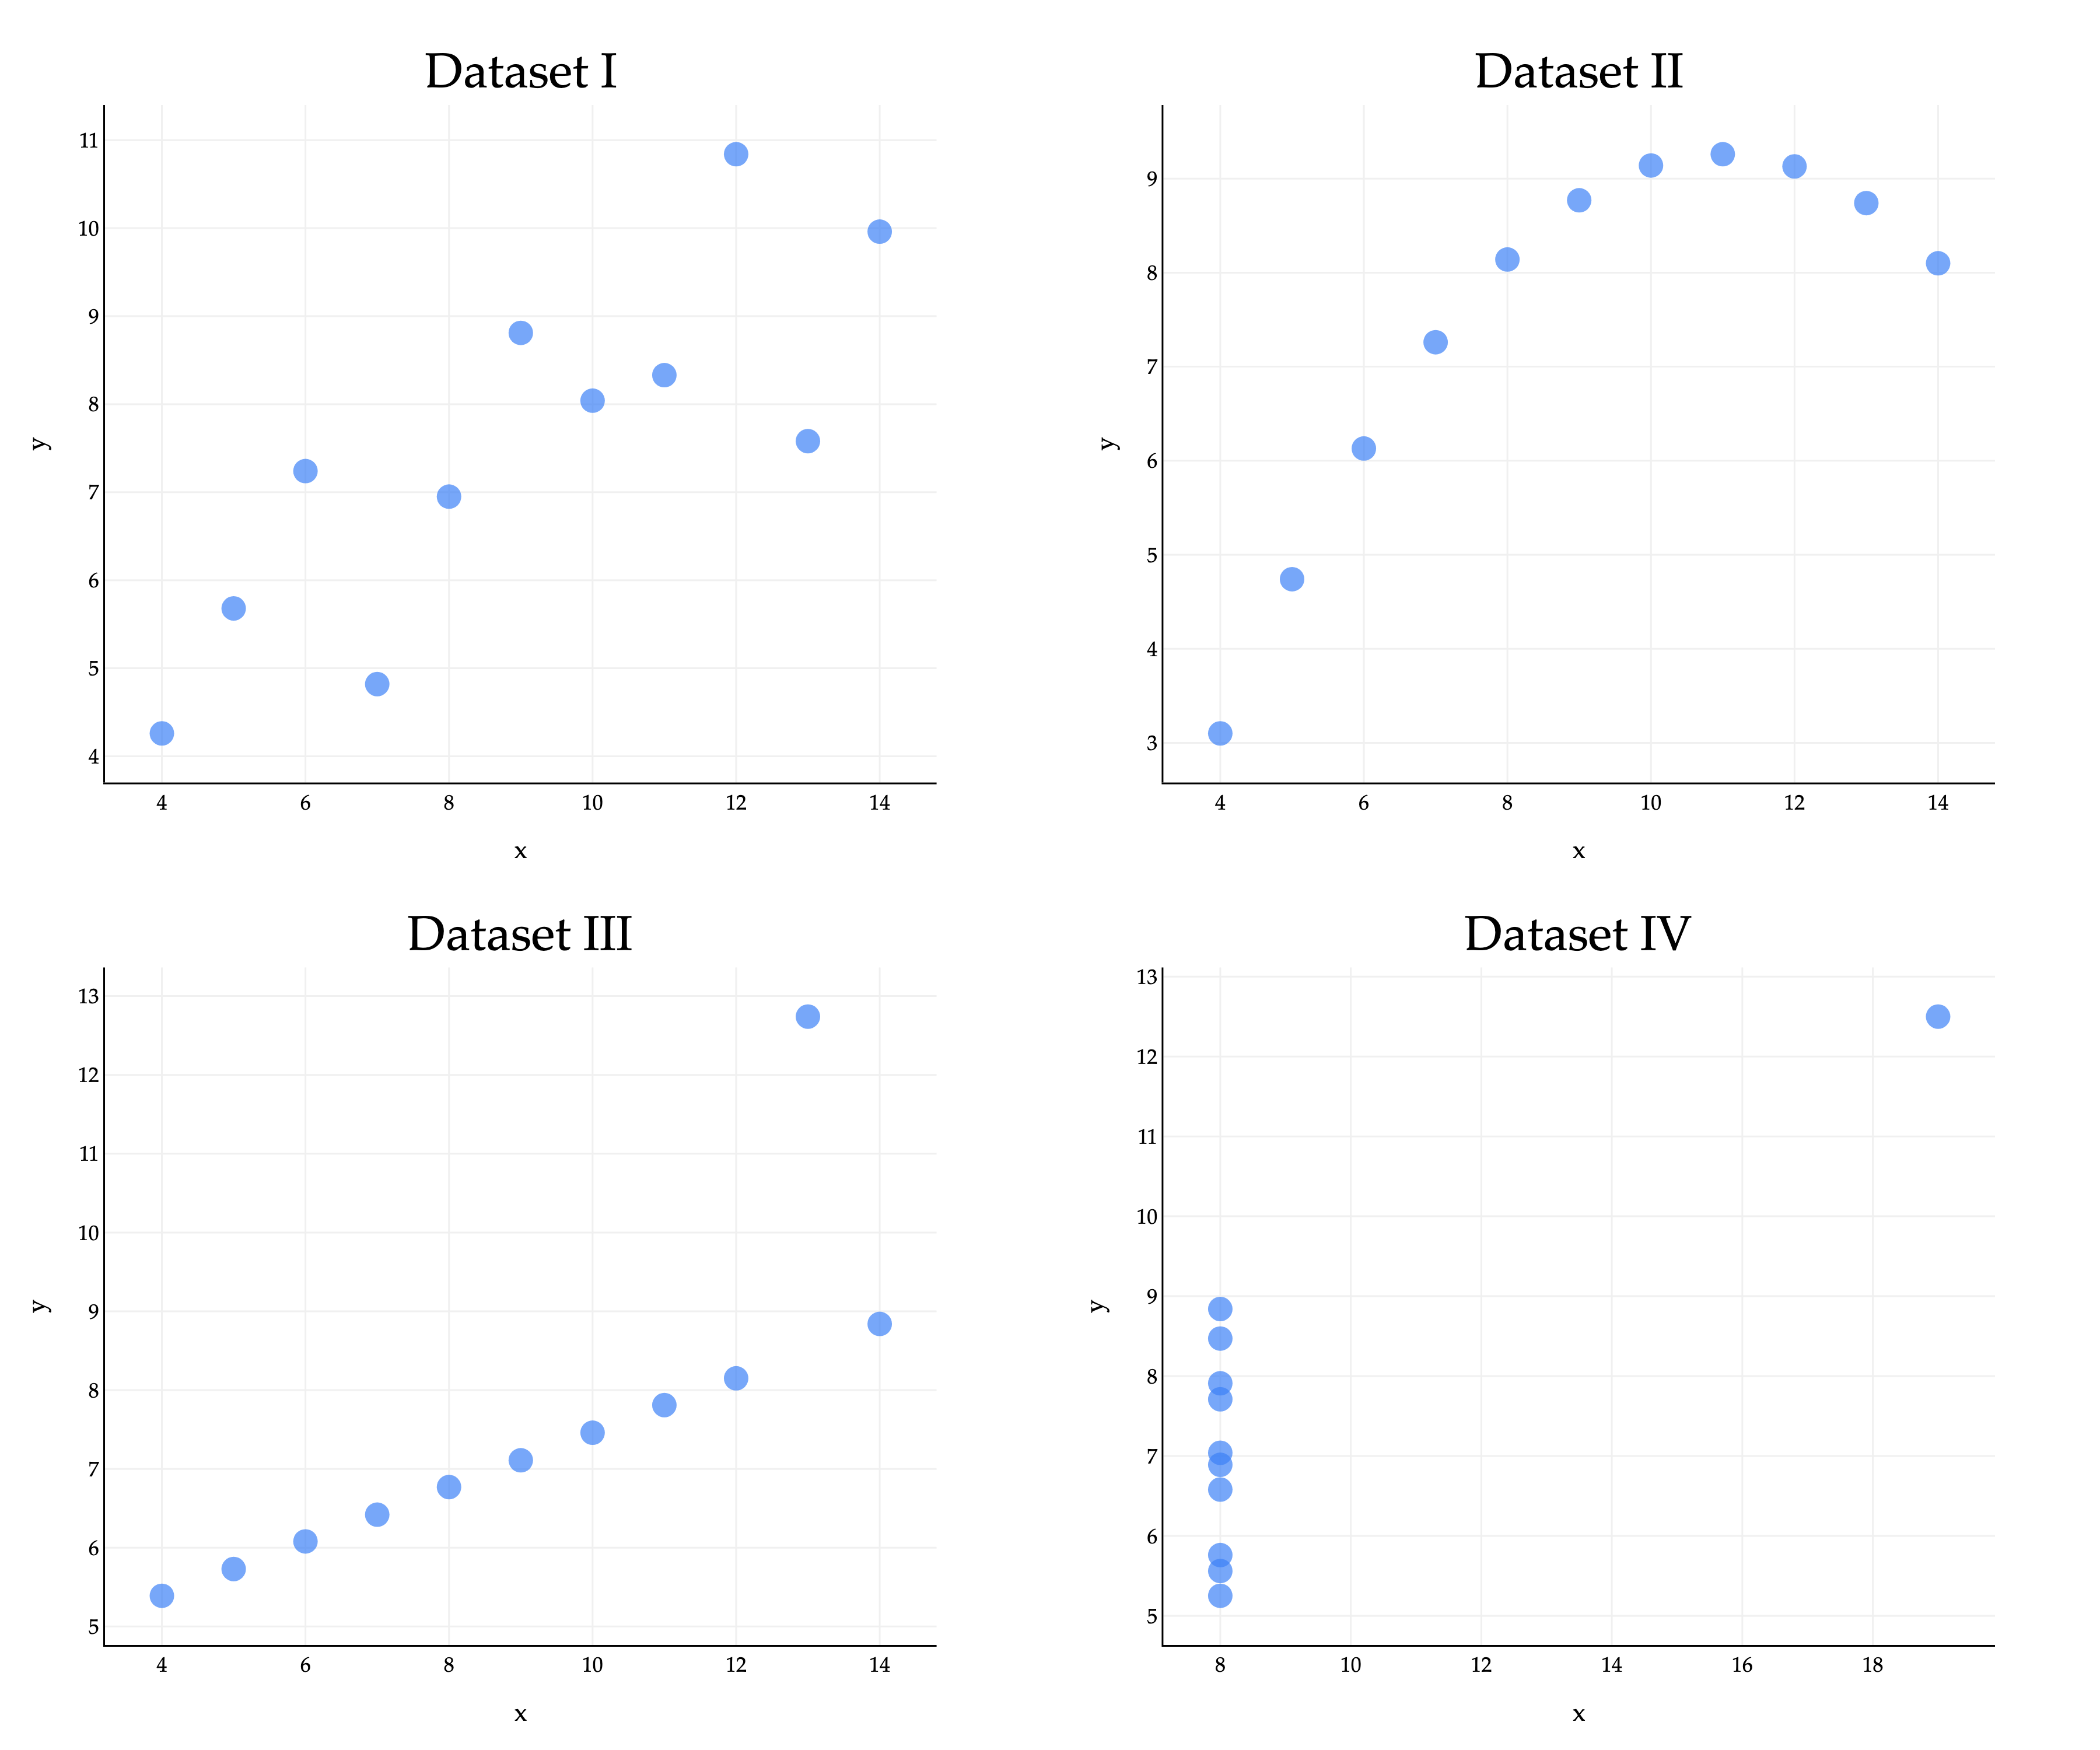

In [58]:
import pandas as pd
import plotly.graph_objects as go
from plotly.subplots import make_subplots

anscombe = pd.read_csv('data/anscombe.csv')

fig = make_subplots(
    rows=2, cols=2,
    subplot_titles=[f"Dataset {n}" for n in ['I', 'II', 'III', 'IV']],
    horizontal_spacing=0.12,
    vertical_spacing=0.12
)

for i, n in enumerate(['I', 'II', 'III', 'IV']):
    rows = anscombe[anscombe['dataset'] == n]
    x = rows['x']
    y = rows['y']
    row = i // 2 + 1
    col = i % 2 + 1
    fig.add_trace(
        go.Scatter(
            x=x, y=y,
            mode='markers',
            marker=dict(size=14, color='#3d81f6', opacity=0.7),
            showlegend=False
        ),
        row=row, col=col
    )

fig.update_layout(
    height=1000,
    width=1200,
    plot_bgcolor='white',
    paper_bgcolor='white',
    margin=dict(l=60, r=60, t=60, b=60),
    font=dict(
        family="Palatino Linotype, Palatino, serif",
        color="black"
    ),
    annotations=[
        dict(font=dict(size=28, family="Palatino Linotype, Palatino, serif"))
    ]
)

for i in range(1, 5):
    fig.update_xaxes(
        title_text="x",
        row=(i-1)//2+1, 
        col=(i-1)%2+1,
        gridcolor='#f0f0f0',
        showline=True,
        linecolor="black",
        linewidth=1,
    )
    fig.update_yaxes(
        title_text="y", 
        row=(i-1)//2+1, 
        col=(i-1)%2+1,
        gridcolor='#f0f0f0',
        showline=True,
        linecolor="black",
        linewidth=1,
    )

fig.show(renderer="png", scale=3)

In all four datasets:

$$\bar{x} = 9, \bar{y} = 7.5, \sigma_x = 3.16, \sigma_y = 1.94, r = 0.82$$

Because they all share the same five values of these key quantities, they also share the same regression lines, since the optimal slope and intercept are determined just using those five quantities.

$$w_1^* = r \frac{\sigma_y}{\sigma_x} = 0.82 \frac{1.94}{3.16} = 0.52 \qquad w_0^* = \bar{y} - w_1^* \bar{x} = 7.5 - 0.52 \cdot 9 = 2.82$$

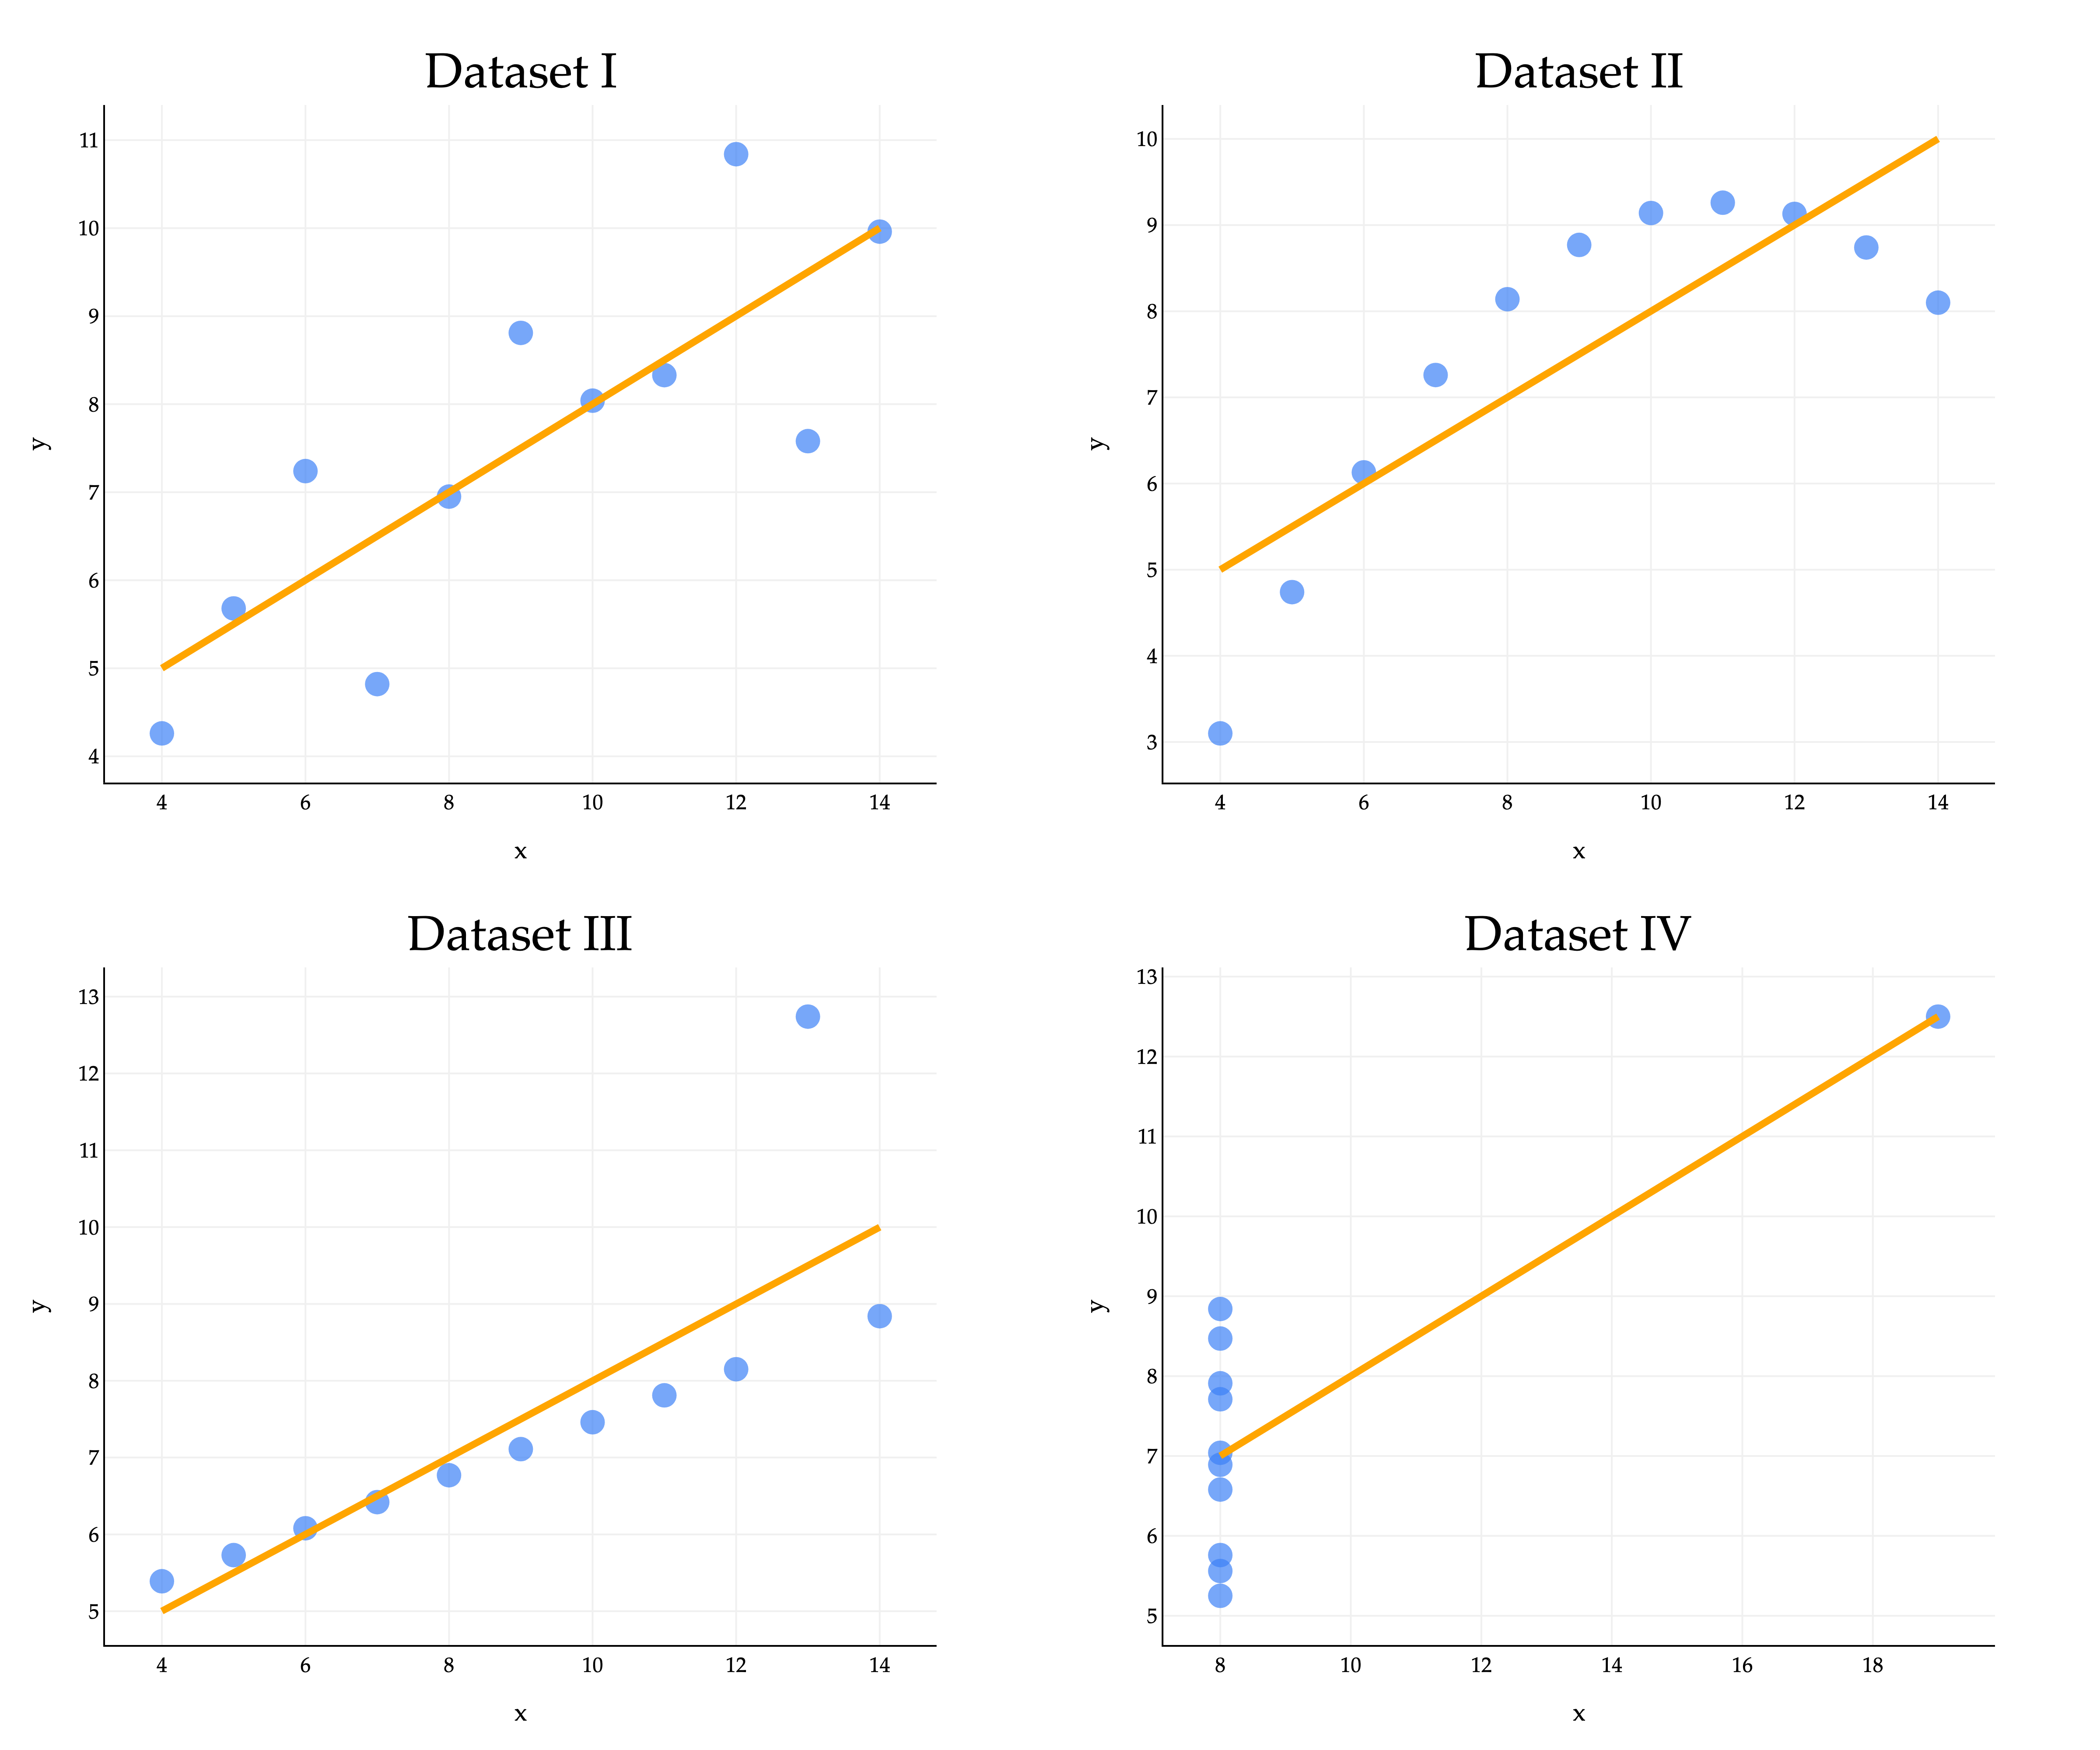

In [61]:
import pandas as pd
import plotly.graph_objects as go
from plotly.subplots import make_subplots

anscombe = pd.read_csv('data/anscombe.csv')

fig = make_subplots(
    rows=2, cols=2,
    subplot_titles=[f"Dataset {n}" for n in ['I', 'II', 'III', 'IV']],
    horizontal_spacing=0.12,
    vertical_spacing=0.12
)

for i, n in enumerate(['I', 'II', 'III', 'IV']):
    rows = anscombe[anscombe['dataset'] == n]
    x = rows['x']
    y = rows['y']
    row = i // 2 + 1
    col = i % 2 + 1
    fig.add_trace(
        go.Scatter(
            x=x, y=y,
            mode='markers',
            marker=dict(size=14, color='#3d81f6', opacity=0.7),
            showlegend=False
        ),
        row=row, col=col
    )

fig.update_layout(
    height=1000,
    width=1200,
    plot_bgcolor='white',
    paper_bgcolor='white',
    margin=dict(l=60, r=60, t=60, b=60),
    font=dict(
        family="Palatino Linotype, Palatino, serif",
        color="black"
    ),
    annotations=[
        dict(font=dict(size=28, family="Palatino Linotype, Palatino, serif"))
    ]
)

for i in range(1, 5):
    fig.update_xaxes(
        title_text="x",
        row=(i-1)//2+1, 
        col=(i-1)%2+1,
        gridcolor='#f0f0f0',
        showline=True,
        linecolor="black",
        linewidth=1,
    )
    fig.update_yaxes(
        title_text="y", 
        row=(i-1)//2+1, 
        col=(i-1)%2+1,
        gridcolor='#f0f0f0',
        showline=True,
        linecolor="black",
        linewidth=1,
    )
for i, n in enumerate(['I', 'II', 'III', 'IV']):
    rows = anscombe[anscombe['dataset'] == n]
    x = rows['x']
    y = rows['y']
    w1_ans = ((x - x.mean()) * (y - y.mean())).sum() / ((x - x.mean()) ** 2).sum()
    w0_ans = y.mean() - w1_ans * x.mean()
    # Sort x for a proper regression line
    x_sorted = np.sort(x)
    y_pred = w0_ans + w1_ans * x_sorted
    row = i // 2 + 1
    col = i % 2 + 1
    # Add regression line to the corresponding subplot
    fig.add_trace(
        go.Scatter(
            x=x_sorted,
            y=y_pred,
            mode='lines',
            line=dict(color='orange', width=4),
            showlegend=False
        ),
        row=row, col=col
    )


fig.show(renderer="png", scale=4)

The regression line clearly looks better for some datasets than others, with Dataset IV looking particularly off. A high $|r|$ may be evidence of a strong linear association, but it cannot guarantee that a linear model is suitable for a dataset. Moral of the story - **visualize your data before trying to fit a model!** Don't _just_ trust the numbers.

You might like the [Datasaurus Dozen](https://jumpingrivers.github.io/datasauRus/), another similar collection of 13 datasets that all have the same mean, standard deviation, and correlation coefficient, but look very different. (One looks like a dinosaur!)

<img src="https://damassets.autodesk.net/content/dam/autodesk/research/publications-assets/gifs/same-stats-different-graphs/DinoSequentialSmaller.gif" width=500>